# Filtering Notebook

This notebook provides you some basic functions for signal analysis and filtering as well as a short example on how to use them.

In [1]:
# Imports (install via pip if necessary)
import scipy.fft as fft
import scipy.signal as sig
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Filtering Functions

In [2]:
def lowpass(signal, fs, order, fc):
    """Butterworth forward-backward low-pass filter.

    :param signal: list of ints or floats; The vector containing the signal samples.
    :param fs: float; The sampling frequency in Hz.
    :param order: int; The order of the filter.
    :param fc: int or float; The cutoff frequency of the filter.

    :return: list of floats; The filtered signal.
    """

    nyq = 0.5 * fs  # Calculate the Nyquist frequency.
    cut = fc / nyq  # Calculate the cutoff frequency (-3 dB).
    lp_b, lp_a = sig.butter(order, cut, btype="lowpass")  # Design and apply the low-pass filter.
    print(f"Filtering Coefficients:\nb: {lp_b}, a: {lp_a}")
    lp_data = list(sig.filtfilt(lp_b, lp_a, signal))  # Apply forward-backward filter with linear phase.

    return lp_data

In [3]:
def highpass(signal, fs, order, fc):
    """Butterworth forward-backward high-pass filter.

    :param signal: list of ints or floats; The vector containing the signal samples.
    :param fs: float; The sampling frequency in Hz.
    :param order: int; The order of the filter.
    :param fc: int or float; The cutoff frequency of the filter.

    :return: list of floats; The filtered signal.
    """

    nyq = 0.5 * fs  # Calculate the Nyquist frequency.
    cut = fc / nyq  # Calculate the cutoff frequency (-3 dB).
    hp_b, hp_a = sig.butter(order, cut, btype="highpass")  # Design and apply the high-pass filter.
    print(f"Filtering Coefficients:\nb: {hp_b}, a: {hp_a}")
    hp_data = list(sig.filtfilt(hp_b, hp_a, signal))  # Apply forward-backward filter with linear phase.

    return hp_data

In [4]:
def bandpass(signal, fs, order, fc_low, fc_hig):
    """Butterworth forward-backward band-pass filter.

    :param signal: list of ints or floats; The vector containing the signal samples.
    :param fs: float; The sampling frequency in Hz.
    :param order: int; The order of the filter.
    :param fc_low: int or float; The lower cutoff frequency of the filter.
    :param fc_hig: int or float; The upper cutoff frequency of the filter.

    :return: list of floats; The filtered signal.
    """

    nyq = 0.5 * fs  # Calculate the Nyquist frequency.
    cut_low = fc_low / nyq  # Calculate the lower cutoff frequency (-3 dB).
    cut_hig = fc_hig / nyq  # Calculate the upper cutoff frequency (-3 dB).
    bp_b, bp_a = sig.butter(order, (cut_low, cut_hig), btype="bandpass")  # Design and apply the band-pass filter.
    print(f"Filtering Coefficients:\nb: {bp_b}, a: {bp_a}")
    bp_data = list(sig.filtfilt(bp_b, bp_a, signal))  # Apply forward-backward filter with linear phase.

    return bp_data

In [5]:
def bandstop(signal, fs, order, fc_low, fc_hig):
    """Butterworth forward-backward band-stop filter.

    :param signal: list of ints or floats; The vector containing the signal samples.
    :param fs: float; The sampling frequency in Hz.
    :param order: int; The order of the filter.
    :param fc_low: int or float; The lower cutoff frequency of the filter.
    :param fc_hig: int or float; The upper cutoff frequency of the filter.

    :return: list of floats; The filtered signal.
    """

    nyq = 0.5 * fs  # Calculate the Nyquist frequency.
    cut_low = fc_low / nyq  # Calculate the lower cutoff frequency (-3 dB).
    cut_hig = fc_hig / nyq  # Calculate the upper cutoff frequency (-3 dB).
    bs_b, bs_a = sig.butter(order, (cut_low, cut_hig), btype="bandstop")  # Design and apply the band-stop filter.
    print(f"Filtering Coefficients:\nb: {bs_b}, a: {bs_a}")
    bs_data = list(sig.filtfilt(bs_b, bs_a, signal))  # Apply forward-backward filter with linear phase.

    return bs_data

In [6]:
def detrend(signal):
    """Tool to detrend the signal, hence to remove the DC offset.

    :param signal: list of ints or floats; The vector containing the signal samples.

    :return: list of floats; The detrended signal.
    """

    return signal - np.mean(signal)  # Zero-Centered

## Frequency Spectrum Functions

In [7]:
def fourier(signal, fs, win="hann", scale="mag"):
    """Tool to apply the discrete fourier transform to obtain the single-sided, real-part frequency spectrum.

    Calculates the 1-dimensional Fast Fourier Transform (FFT) for real-valued input data and produces the non-redundant positive frequency components.
    This approach takes advantage of symmetry to reduce computation time and memory usage, which makes it effective for real-world signals.

    :param signal: list of ints or floats; The vector containing the signal samples.
    :param fs: float; The sampling frequency in Hz.
    :param win: String, default="hann";
    :param scale: String, default="mag"; The scaling of the values, so magnitude or power spectrum, or nothing applied.

    :return bin: ndarray; The array of sample frequencies, frequency bins respectively.
    :return mag: ndarray; The magnitudes of the frequency spectral components of the signal.
    """

    # Fast Fourier transform with applied window function and scaling
    fft_bin = fft.rfftfreq(len(signal), d=1.0/fs)  # Generate list of frequency bins
    window = sig.windows.get_window(win, len(signal))  # Apply window function, default: Hann

    if scale == "mag":
        fft_mag = 2.0/len(signal) * np.abs(fft.rfft(window * signal))  # Single-sided, real-part DFT (FFT) with magnitude scale
    elif scale == "pwr":
        fft_mag = np.abs(fft.rfft(window * signal))**2  # Single-sided, real-part DFT (FFT) with spectral power scale
    else:
        fft_mag = np.abs(fft.rfft(window * signal))  # Original values from single-sided, real-part DFT (FFT)

    return fft_bin, fft_mag

In [8]:
def welch(signal, fs, n_seg, n_fft, win="hann", mode="density"):
    """Tool to apply Welch's method for the estimation of the power spectral density or power spectrum.

    :param signal: list of ints or floats; The vector containing the signal samples.
    :param fs: float; The sampling frequency in Hz.
    :param n_seg: int; The length of the window segments.
    :param n_fft: int; The number of samples taken for the FFT of each window segment, usually n_fft = n_seg.
    :param win: String, default="hann";
    :param mode: String, default="density"; The power spectral density "density" where Pxx has units of V**2/Hz or
        the power spectrum "spectrum" where Pxx has units of V**2.

    :return bin: ndarray; The array of sample frequencies.
    :return psd: ndarray; The power spectral density or power spectrum of the signal.
    """

    # Welch's Power Spectral Density Estimation
    # default: noverlap=n_seg/2
    psd_bin, psd_mag = sig.welch(np.array(signal), fs, window=win, nperseg=n_seg, nfft=n_fft, return_onesided=True, scaling=mode)

    return psd_bin, psd_mag

## WalkStand.csv Analysis

The raw file contains the axes x, y, and z without a time column. Set the sampling rate below to match the acquisition rate used for the data. The workflow uses the resultant magnitude as the aggregation technique because it is orientation-independent and usually produces the clearest step-frequency peak for walking data.

Recommended configuration for step counting:
- aggregation: resultant magnitude sqrt(x^2 + y^2 + z^2)
- preprocessing: detrend to remove the DC and gravity offset
- filter: 4th-order Butterworth bandpass around 0.5 to 6.0 Hz
- step detection: count peaks on the filtered magnitude

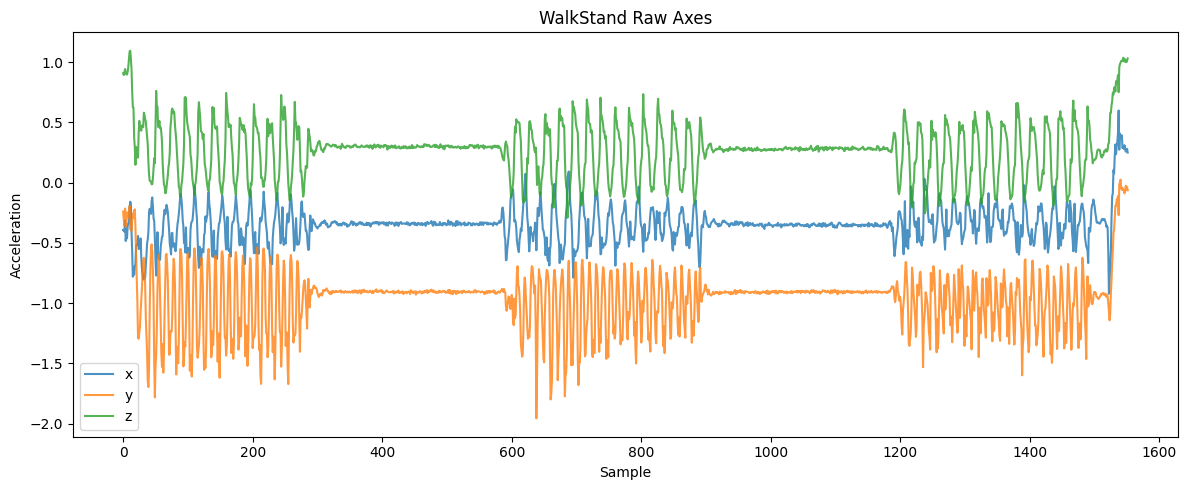

In [ ]:
# Load WalkStand data
df_walk = pd.read_csv("WalkStand.csv")
x = df_walk["x"].to_numpy()
y = df_walk["y"].to_numpy()
z = df_walk["z"].to_numpy()

# Sampling frequency of the WalkStand data
fs_walkstand = 20.0

sample_idx = np.arange(len(df_walk))

plt.figure(figsize=(12, 5))
plt.plot(sample_idx, x, label="x", alpha=0.8)
plt.plot(sample_idx, y, label="y", alpha=0.8)
plt.plot(sample_idx, z, label="z", alpha=0.8)
plt.title("WalkStand Raw Axes")
plt.xlabel("Sample")
plt.ylabel("Acceleration")
plt.legend()
plt.tight_layout()
plt.show()

Dominant frequency in 0.5 to 6.0 Hz: 4.59 Hz
For step counting, a clear peak in the 1 to 3 Hz range usually indicates walking cadence, but harmonics can extend the useful band higher.


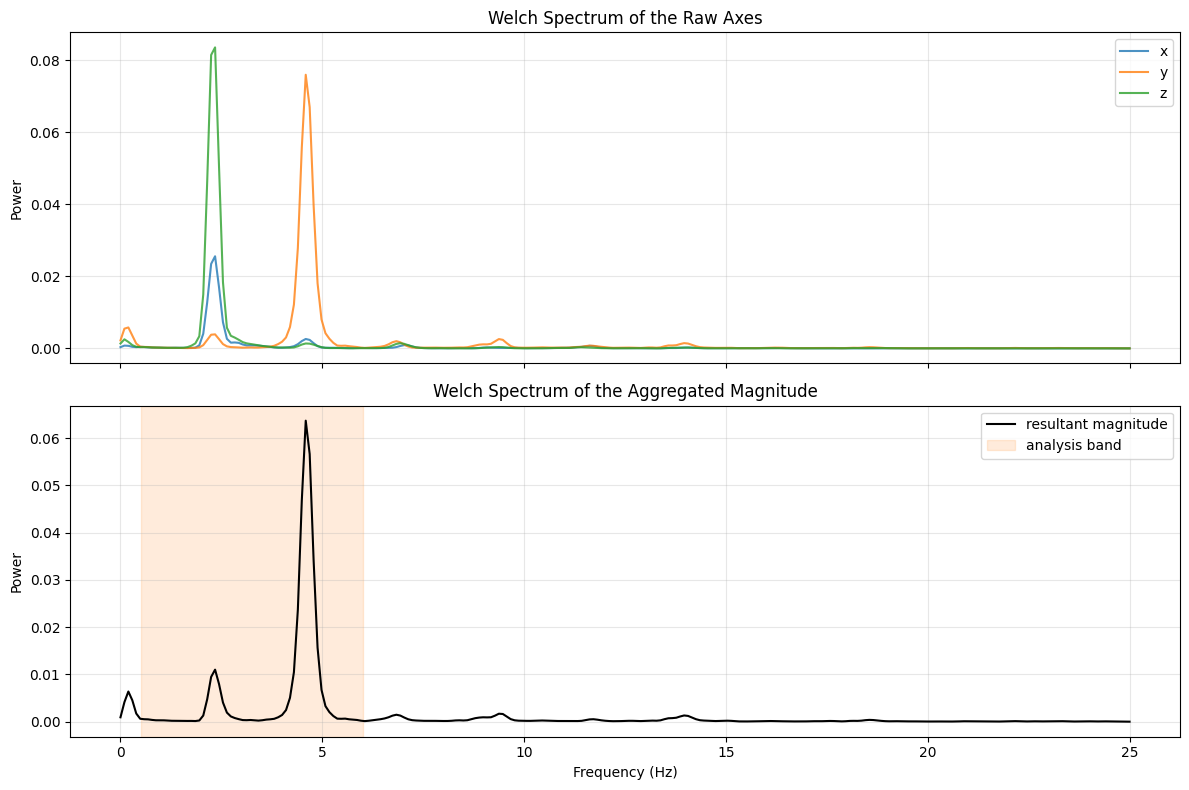

In [11]:
# Aggregate the three axes into an orientation-independent signal
acc_mag = np.sqrt(x**2 + y**2 + z**2)
acc_mag_detrended = detrend(acc_mag)

# Compare the spectra of the raw axes and the aggregated magnitude
n_seg = min(256, len(acc_mag_detrended))
n_fft = max(512, 2 ** int(np.ceil(np.log2(n_seg))))

freq_x, psd_x = welch(detrend(x), fs_walkstand, n_seg, n_fft)
freq_y, psd_y = welch(detrend(y), fs_walkstand, n_seg, n_fft)
freq_z, psd_z = welch(detrend(z), fs_walkstand, n_seg, n_fft)
freq_mag, psd_mag = welch(acc_mag_detrended, fs_walkstand, n_seg, n_fft)

analysis_band = (0.5, 6.0)
band_mask = (freq_mag >= analysis_band[0]) & (freq_mag <= analysis_band[1])
dominant_freq = freq_mag[band_mask][np.argmax(psd_mag[band_mask])]

print(f"Dominant frequency in {analysis_band[0]} to {analysis_band[1]} Hz: {dominant_freq:.2f} Hz")
print("For step counting, a clear peak in the 1 to 3 Hz range usually indicates walking cadence, but harmonics can extend the useful band higher.")

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
axes[0].plot(freq_x, psd_x, label="x", alpha=0.8)
axes[0].plot(freq_y, psd_y, label="y", alpha=0.8)
axes[0].plot(freq_z, psd_z, label="z", alpha=0.8)
axes[0].set_title("Welch Spectrum of the Raw Axes")
axes[0].set_ylabel("Power")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(freq_mag, psd_mag, color="black", label="resultant magnitude")
axes[1].axvspan(analysis_band[0], analysis_band[1], color="tab:orange", alpha=0.15, label="analysis band")
axes[1].set_title("Welch Spectrum of the Aggregated Magnitude")
axes[1].set_xlabel("Frequency (Hz)")
axes[1].set_ylabel("Power")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Filtering Coefficients:
b: [ 0.00666134  0.         -0.02664535  0.          0.03996802  0.
 -0.02664535  0.          0.00666134], a: [  1.          -6.05609832  16.18939178 -25.04241877  24.58335278
 -15.70313322   6.37286735  -1.50121685   0.15725756]


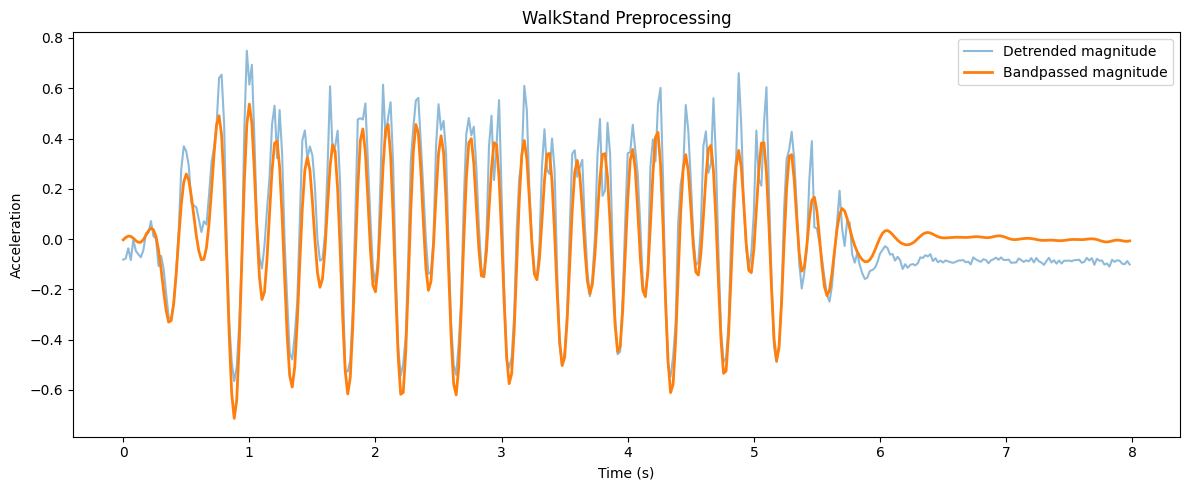

In [12]:
# Bandpass filter the aggregated magnitude for step-oriented preprocessing
order_walk = 4
fc_low_walk = 0.5
fc_high_walk = 6.0

walk_bandpassed = bandpass(acc_mag_detrended, fs_walkstand, order_walk, fc_low_walk, fc_high_walk)
time_walk = np.arange(len(acc_mag_detrended)) / fs_walkstand

plt.figure(figsize=(12, 5))
plt.plot(time_walk[:400], acc_mag_detrended[:400], label="Detrended magnitude", alpha=0.5)
plt.plot(time_walk[:400], walk_bandpassed[:400], label="Bandpassed magnitude", linewidth=2)
plt.title("WalkStand Preprocessing")
plt.xlabel("Time (s)")
plt.ylabel("Acceleration")
plt.legend()
plt.tight_layout()
plt.show()

Estimated step count from the filtered magnitude: 43
Peak distance constraint: 17 samples
Peak prominence threshold: 0.0602


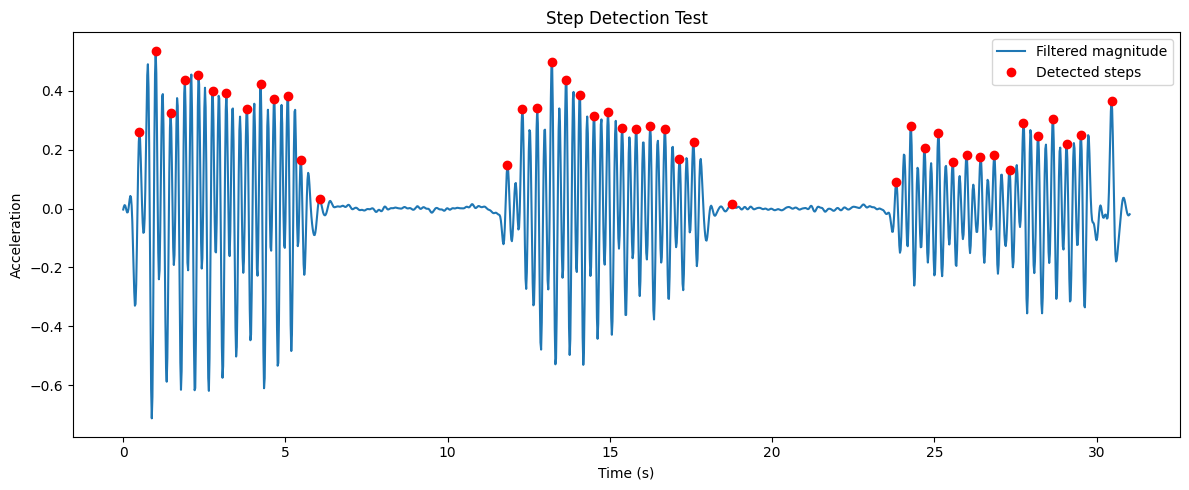

In [14]:
# Simple step-counting test on the filtered magnitude
filtered_walk = np.asarray(walk_bandpassed)
distance_samples = int(0.35 * fs_walkstand)
prominence = 0.35 * np.std(filtered_walk)

peaks, properties = sig.find_peaks(
    filtered_walk,
    distance=distance_samples,
    prominence=prominence,
 )
step_count = len(peaks)

print(f"Estimated step count from the filtered magnitude: {step_count}")
print(f"Peak distance constraint: {distance_samples} samples")
print(f"Peak prominence threshold: {prominence:.4f}")

plt.figure(figsize=(12, 5))
plt.plot(time_walk, filtered_walk, label="Filtered magnitude")
plt.plot(time_walk[peaks], filtered_walk[peaks], "ro", label="Detected steps")
plt.title("Step Detection Test")
plt.xlabel("Time (s)")
plt.ylabel("Acceleration")
plt.legend()
plt.tight_layout()
plt.show()

## Reasoning

The chosen processing chain is appropriate for step counting because it keeps the periodic movement signal while removing sources of distortion that are not useful for cadence estimation.

1. The resultant magnitude combines the x, y, and z axes into one orientation-independent signal, which is better than relying on a single axis when the sensor orientation can change.
2. Detrending removes the constant offset caused by gravity and sensor bias, so the spectrum and peak detector focus on motion instead of the baseline.
3. Welch’s method is used for the spectral analysis because it averages multiple FFT segments and gives a smoother, more stable estimate of the dominant walking frequency than a single FFT.
4. The 0.5 to 6.0 Hz bandpass filter keeps the frequency range where walking cadence and its nearby harmonics appear, while suppressing slow drift and higher-frequency noise.
5. The peak detector then counts likely steps by enforcing a minimum spacing and a prominence threshold, which reduces false detections from small oscillations.

In short, these steps are correct because they match the structure of walking data: periodic, low-frequency motion with a strong dependence on sensor orientation and baseline drift.